In [98]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [99]:
df = pd.read_csv(r"C:\TECH FEST\archive sensor data\agriculture_dataset.csv")

In [100]:
print(df.head())
print(df.shape)
print(df.columns)

   High_Resolution_RGB  Multispectral_Images  Thermal_Images  Temporal_Images  \
0                    0                     0               0                0   
1                    1                     1               0                0   
2                    0                     0               0                0   
3                    0                     0               0                0   
4                    0                     1               1                1   

   Spatial_Resolution  GPS_Coordinates  Field_Boundaries  Elevation_Data  \
0            0.667324           201538                 3       28.207634   
1            1.459000           215854                 3       82.335147   
2            0.500442           890802                 3       83.865629   
3            1.865161           605584                 3       20.747905   
4            1.392331           871732                 3       22.588815   

   Canopy_Coverage      NDVI  ...  Weed_Coverage  Pest_D

In [101]:
df.columns

Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='str')

In [102]:
df.head(10)

,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0
5,0,0,0,0,2.342274,251493,3,46.683234,29.525247,0.507520,...,4.426726,1,1,3186.428122,Wheat,0,6,41.304044,0,0
6,0,0,0,0,1.745272,665471,3,20.582658,22.422320,0.499019,...,0.892302,58,1,3096.231256,Wheat,0,9,3.313661,1,0
7,1,0,0,0,2.040050,899698,2,60.352718,76.419390,0.602585,...,4.115669,37,2,3759.071392,Wheat,0,6,29.300177,1,1
8,0,0,1,0,0.862034,300672,3,23.027399,3.294899,0.500893,...,1.884896,21,3,2492.937443,Wheat,1,4,18.688151,0,1
9,0,0,0,0,0.840869,452663,3,48.297885,299.805468,0.558419,...,4.406684,91,3,2660.762241,Wheat,0,7,23.678779,0,0


In [103]:
# Original DataFrame
print(df.columns)
# 32 columns

# Keep only 4 columns
df = df[['Temperature', 'Humidity', 'Soil_Moisture', 'Crop_Health_Label']]

print(df.columns)

Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='str')
Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Crop_Health_Label'], dtype='str')


In [104]:
df.shape

(212019, 4)

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212019 entries, 0 to 212018
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Temperature        212019 non-null  float64
 1   Humidity           212019 non-null  float64
 2   Soil_Moisture      212019 non-null  float64
 3   Crop_Health_Label  212019 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 6.5 MB


In [106]:
df.describe()

,Temperature,Humidity,Soil_Moisture,Crop_Health_Label
count,212019.000000,212019.000000,212019.000000,212019.000000
mean,24.988813,60.026018,20.036496,0.698985
std,4.998123,17.300364,8.657071,0.458701
min,2.683095,30.000070,5.000124,0.000000
25%,21.618165,45.077182,12.560251,0.000000
50%,24.983795,60.049335,20.062687,1.000000
75%,28.363127,74.972133,27.543781,1.000000
max,46.783110,89.999833,34.999900,1.000000


### Feature analysis

| Column            |    Mean |   Std |    Min |     Max | Interpretation                             |
| ----------------- | ------: | ----: | -----: | ------: | ------------------------------------------ |
| Temperature       | 24.99°C |  5.00 | 2.68°C | 46.78°C | Average temperature is around 25°C         |
| Humidity          |  60.03% | 17.30 | 30.00% |  90.00% | Data covers dry to highly humid conditions |
| Soil Moisture     |   20.04 |  8.66 |   5.00 |   35.00 | Soil moisture varies widely                |
| Crop Health Label |   0.699 | 0.459 |      0 |       1 | About 70% samples are healthy              |


In [107]:
df.isnull().sum()

Temperature          0
Humidity             0
Soil_Moisture        0
Crop_Health_Label    0
dtype: int64

### Interpretation:

- No missing values in Temperature
- No missing values in Humidity
- No missing values in Soil Moisture
- No missing values in the target label

 So no need any missing-value handling.

In [108]:
df.duplicated().sum()

np.int64(0)

- Means there are no duplicate rows in dataset. 

In [109]:
df['Crop_Health_Label'].value_counts()

Crop_Health_Label
1    148198
0     63821
Name: count, dtype: int64

|             Label |       Count | Percentage |
| ----------------: | ----------: | ---------: |
|   **Healthy (1)** | **148,198** | **69.90%** |
| **Unhealthy (0)** |  **63,821** | **30.10%** |


## EDA visualizations.

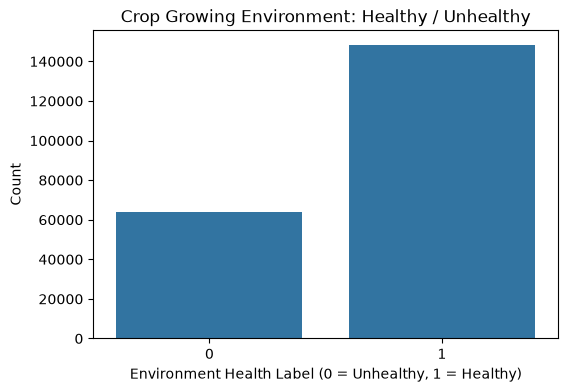

In [110]:
#1. Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Crop_Health_Label', data=df)
plt.title("Crop Growing Environment: Healthy / Unhealthy")
plt.xlabel("Environment Health Label (0 = Unhealthy, 1 = Healthy)")
plt.ylabel("Count")
plt.show()

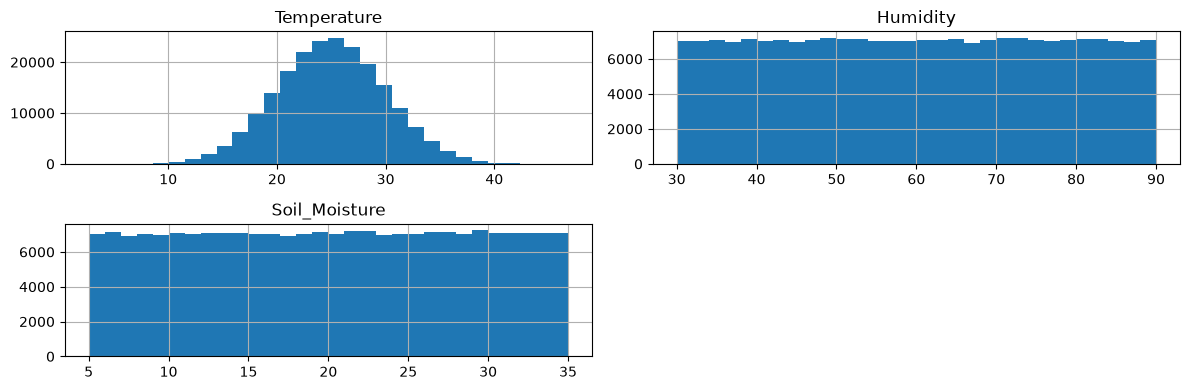

In [111]:
# 2. Histograms

df[['Temperature','Humidity','Soil_Moisture']].hist(
    figsize=(12,4),
    bins=30
)
plt.tight_layout()
plt.show()

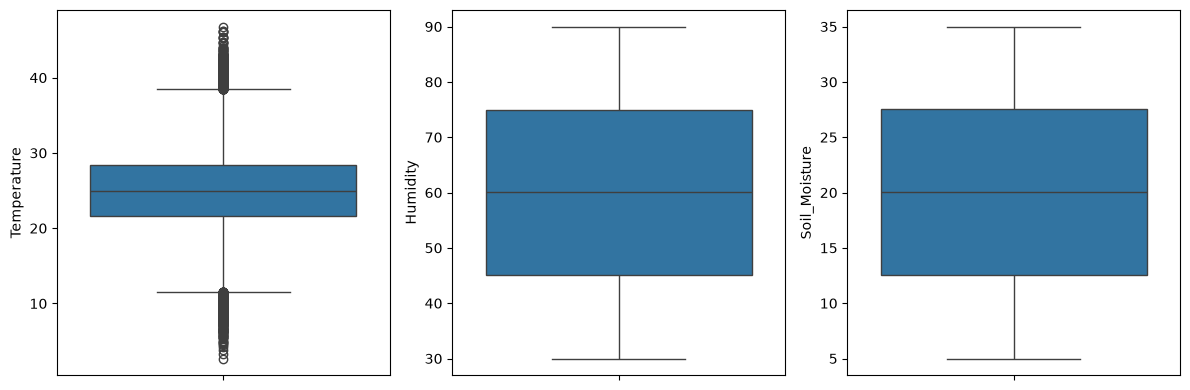

In [112]:
# 3. Boxplots

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Temperature'])

plt.subplot(1,3,2)
sns.boxplot(y=df['Humidity'])

plt.subplot(1,3,3)
sns.boxplot(y=df['Soil_Moisture'])

plt.tight_layout()
plt.show()

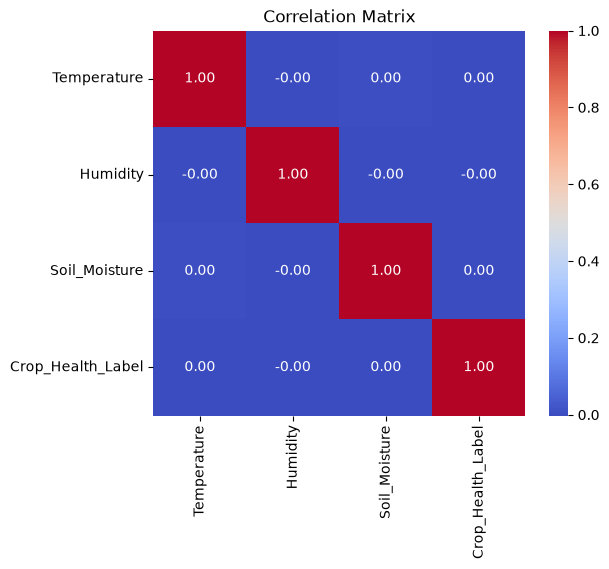

In [113]:
#4. Correlation Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

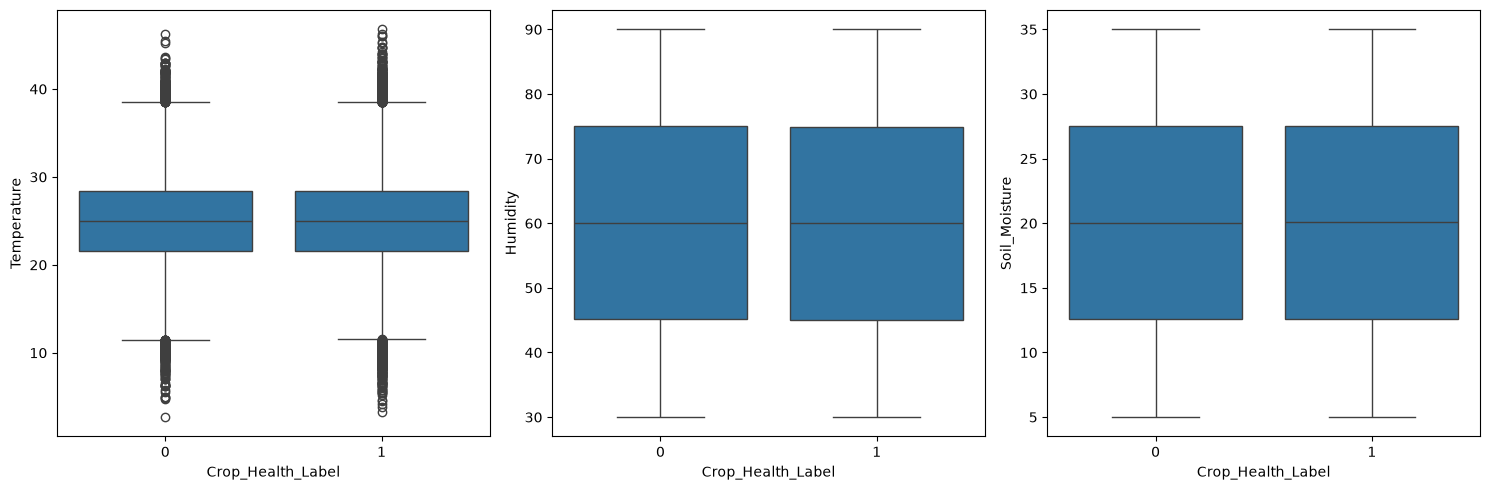

In [114]:
# Feature vs Target

fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(x='Crop_Health_Label', y='Temperature', data=df, ax=axes[0])
sns.boxplot(x='Crop_Health_Label', y='Humidity', data=df, ax=axes[1])
sns.boxplot(x='Crop_Health_Label', y='Soil_Moisture', data=df, ax=axes[2])

plt.tight_layout()
plt.show()